# PPE Detection with YOLO11s: Frozen Backbone vs Partial Fine-Tuning

## Project overview

This is a **new, independent YOLO11s experiment** on the same four-class curated PPE dataset used in the YOLOv8s study. The dataset contains 3,403 training, 993 validation, and 500 test images. Classes: Hardhat, NO-Hardhat, Safety Vest, and NO-Safety Vest.

1. Restore the dataset archive in a GPU-enabled Colab runtime.
2. Inspect `yolo11s.pt` and determine its backbone boundary from the model configuration.
3. Create the same training-only oversampling list and use the same augmentation, optimizer, epochs, and image size as the earlier YOLOv8s experiment.
4. Train two fresh YOLO11s models: freeze the whole backbone, or unfreeze its last two modules. Neither strategy uses full fine-tuning.
5. Compare the best checkpoints on **validation**; then evaluate the selected one once on **test**.

No results from the earlier experiment have been copied into this notebook. The test split must not be used to choose a freezing strategy.


## Step 1 — Install the training library

We use Ultralytics to train **YOLO11s** (Small) to detect Hardhat, NO-Hardhat, Safety Vest, and NO-Safety Vest. The `s` model is larger than Nano, as intended for this project. We begin with pretrained weights rather than training from scratch. The next code cell installs the library in this Colab runtime; it does not start training.


In [ ]:
%pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 949.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.1 MB/s eta 0:00:00


## Step 2 — Restore and check the dataset

The dataset ZIP is stored in Google Drive so it survives Colab restarts. The next cell mounts Drive and extracts the files into `/content` for training. The following cell checks the GPU, the dataset folder, and the class names in `data.yaml`. It does not modify image annotations.


### Restore the dataset from Google Drive

The ZIP is an input archive. Images and labels are extracted to Colab's local workspace; the training loop reads them there. Check `ZIP_PATH` if your Drive file has a different name.


In [ ]:
from google.colab import drive
from pathlib import Path
import zipfile

drive.mount("/content/drive")

ZIP_PATH = Path("/content/drive/MyDrive/ppe_4class_v3.zip")
DATA_ROOT = Path("/content/ppe_curated_4class_v3_merged_review")

assert ZIP_PATH.exists(), "عدلي ZIP_PATH إلى مكان ملف ZIP في درايف."

if not DATA_ROOT.exists():
    with zipfile.ZipFile(ZIP_PATH) as archive:
        archive.extractall(DATA_ROOT)

assert (DATA_ROOT / "data.yaml").exists(), "تأكدي من اكتمال فك الضغط."
print("Dataset ready:", DATA_ROOT)

Mounted at /content/drive
Dataset ready: /content/ppe_curated_4class_v3_merged_review


In [ ]:
import torch
import yaml
from ultralytics import YOLO

DATA_ROOT = Path("/content/ppe_curated_4class_v3_merged_review")

print("GPU available:", torch.cuda.is_available())
print("Dataset available:", DATA_ROOT.exists())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

if (DATA_ROOT / "data.yaml").exists():
    config = yaml.safe_load((DATA_ROOT / "data.yaml").read_text())
    print("Classes:", config["names"])

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
GPU available: True
Dataset available: True
GPU: Tesla T4
Classes: {0: 'Hardhat', 1: 'NO-Hardhat', 2: 'Safety Vest', 3: 'NO-Safety Vest'}


## Step 3 — Inspect the pretrained YOLO11s model

Load `yolo11s.pt` and calculate `BACKBONE_END` from its actual model configuration. The backbone extracts image features; the neck combines them, and the detection head predicts class labels and bounding boxes. YOLO11s need not have the same backbone boundary as YOLOv8s, so the training cells use this calculated number instead of a hard-coded freeze value. This step does not train the model.


In [ ]:
from ultralytics import YOLO

assert torch.cuda.is_available()

model = YOLO("yolo11s.pt")
BACKBONE_END = len(model.model.yaml["backbone"])

print("Backbone modules:", BACKBONE_END)
print("Index | Section | Module")

for index, layer in enumerate(model.model.model):
    section = "Backbone" if index < BACKBONE_END else "Neck / Head"
    print(f"{index:2} | {section:11} | {type(layer).__name__}")

Backbone modules: 11
Index | Section | Module
 0 | Backbone    | Conv
 1 | Backbone    | Conv
 2 | Backbone    | C3k2
 3 | Backbone    | Conv
 4 | Backbone    | C3k2
 5 | Backbone    | Conv
 6 | Backbone    | C3k2
 7 | Backbone    | Conv
 8 | Backbone    | C3k2
 9 | Backbone    | SPPF
10 | Backbone    | C2PSA
11 | Neck / Head | Upsample
12 | Neck / Head | Concat
13 | Neck / Head | C3k2
14 | Neck / Head | Upsample
15 | Neck / Head | Concat
16 | Neck / Head | C3k2
17 | Neck / Head | Conv
18 | Neck / Head | Concat
19 | Neck / Head | C3k2
20 | Neck / Head | Conv
21 | Neck / Head | Concat
22 | Neck / Head | C3k2
23 | Neck / Head | Detect


## Step 4 — Prepare training data and augmentation

`NO-Safety Vest` was less represented in the curated data. Each **training** image containing it appears twice in a text file of image paths; other training images appear once. This is repeated exposure, not a new photograph. If a repeated image contains other classes, their boxes are seen more often too. Validation and test images remain at their original frequencies.

We explicitly set a 50% horizontal-flip probability and modest HSV color/brightness changes. **Important for reproducibility:** the saved training logs also show Ultralytics defaults `mosaic=1.0`, `translate=0.1`, and `scale=0.5`; mosaic was disabled for the last ten epochs (`close_mosaic=10`). Thus the actual training used more transformations than the explicitly listed flip and HSV settings. They were applied to training images, while validation and test evaluation used their original images. Both strategies shared the same image list and settings.

The `COMMON_SETTINGS` dictionary keeps epochs, image size, batch size, optimizer, learning rate, device, and output folder consistent. `device=0` uses the first GPU; `workers=2` uses two CPU data-loading workers. The `project` path saves checkpoints and logs in Drive so they survive a Colab disconnect.


In [ ]:
TARGET_CLASSES = {0: 2, 3: 2}   # Hardhat and NO-Safety Vest each appear twice
TARGET_REPEATS = max([TARGET_CLASSES.get(c, 1) for c in classes] or [1])
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

train_paths = []
target_images = 0
original_images = 0

for image in sorted((DATA_ROOT / "train/images").iterdir()):
    if image.suffix.lower() not in IMAGE_EXTENSIONS:
        continue

    label = DATA_ROOT / "train/labels" / f"{image.stem}.txt"
    assert label.exists(), f"Missing label: {label.name}"

    classes = {
        int(line.split()[0])
        for line in label.read_text().splitlines()
        if line.strip()
    }

    contains_target = TARGET_CLASS in classes
    repeats = TARGET_REPEATS if contains_target else 1

    train_paths.extend([str(image.resolve())] * repeats)
    target_images += contains_target
    original_images += 1

assert train_paths, "No training images found."

TRAIN_LIST = Path("/content/ppe_train_oversampled.txt")
TRAIN_LIST.write_text("\n".join(train_paths) + "\n")

# Write a new YAML without changing the original dataset file
config = yaml.safe_load((DATA_ROOT / "data.yaml").read_text())
config.update(
    path=str(DATA_ROOT),
    train=str(TRAIN_LIST),
    val=str(DATA_ROOT / "valid/images"),
    test=str(DATA_ROOT / "test/images"),
)

DATA_YAML = Path("/content/ppe_training_data.yaml")
DATA_YAML.write_text(yaml.safe_dump(config, sort_keys=False))

# Shared settings for both strategies
COMMON_SETTINGS = dict(
    data=str(DATA_YAML),
    epochs=20,
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    lr0=0.001,
    seed=42,
    device=0,
    workers=2,
    plots=True,
    project="/content/drive/MyDrive/ppe_experiments_yolo11",

    # Augmentation
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.2,
    hsv_v=0.2,


)

print("Original training images:", original_images)
print("Images containing NO-Safety Vest:", target_images)
print("Training entries per epoch:", len(train_paths))

Original training images: 3403
Images containing NO-Safety Vest: 661
Training entries per epoch: 4064


## Step 5 — Train strategy 1: freeze the entire backbone

`freeze=BACKBONE_END` freezes every backbone module in the inspected YOLO11s architecture. The neck and detection head remain trainable. Start from the pretrained `yolo11s.pt` weights and run the same 20-epoch settings as strategy 2. `RUN_1` records this experiment's checkpoint and history directory.


In [ ]:
from ultralytics import YOLO

strategy_1 = YOLO("yolo11s.pt")

strategy_1.train(
    **COMMON_SETTINGS,
    freeze=BACKBONE_END,
    name="strategy_1_yolo11_backbone_frozen",
)

RUN_1 = Path(strategy_1.trainer.save_dir)
print("Results saved to:", RUN_1)

Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_training_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=11, hsv_h=0.015, hsv_s=0.2, hsv_v=0.2, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=strategy_1_yolo11_backbone_frozen, nbs=64, nms=None, opset

## Step 6 — Read strategy 1's training history

The three plots compare training and validation losses for bounding boxes (`box`), classes (`cls`), and box localization (`dfl`) over epochs. The other plot shows **validation** mAP50 and mAP50-95 over epochs. Lower losses and higher mAP can indicate progress, but a persistent training/validation gap alone does not prove leakage or overfitting. This cell reads saved results; it does not train or use test data.


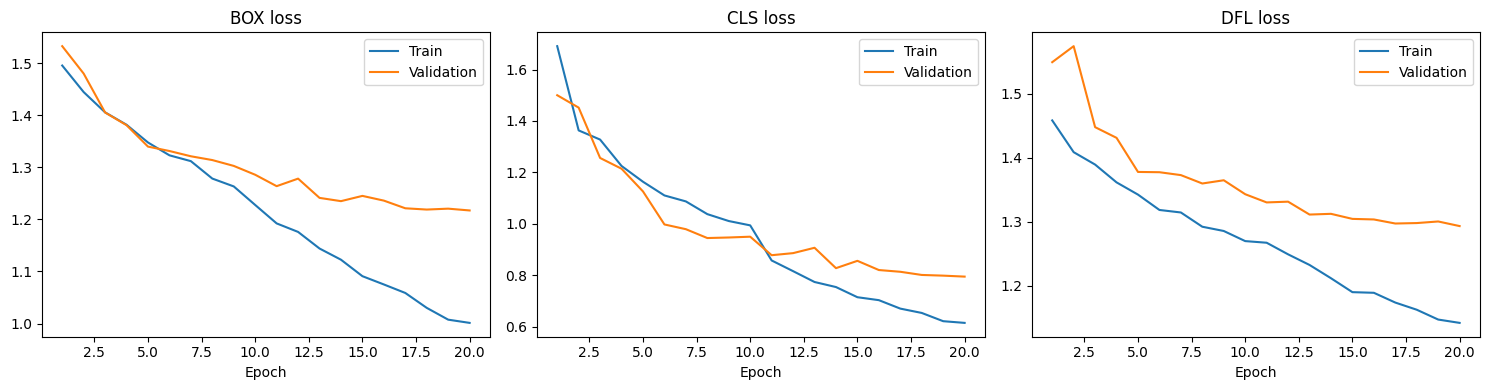

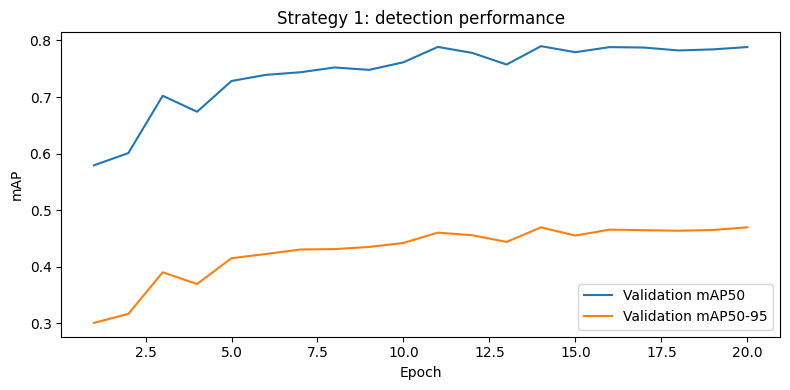

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

history_1 = pd.read_csv(RUN_1 / "results.csv")
history_1.columns = history_1.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, component in zip(axes, ["box", "cls", "dfl"]):
    ax.plot(history_1["epoch"], history_1[f"train/{component}_loss"],
            label="Train")
    ax.plot(history_1["epoch"], history_1[f"val/{component}_loss"],
            label="Validation")
    ax.set_title(f"{component.upper()} loss")
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_1["epoch"], history_1["metrics/mAP50(B)"],
         label="Validation mAP50")
plt.plot(history_1["epoch"], history_1["metrics/mAP50-95(B)"],
         label="Validation mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Strategy 1: detection performance")
plt.legend()
plt.tight_layout()
plt.show()

## Step 7 — Train strategy 2: partial backbone fine-tuning

Load **another fresh** `yolo11s.pt` model. `freeze=BACKBONE_END - 2` leaves the last two backbone modules trainable while earlier backbone modules stay frozen. The neck and detection head also train. Both strategies start independently from the same pretrained checkpoint and share the same dataset, oversampling, augmentation, and optimization settings.


In [ ]:
strategy_2 = YOLO("yolo11s.pt")

strategy_2.train(
    **COMMON_SETTINGS,
    freeze=BACKBONE_END - 2,
    name="strategy_2_yolo11_partial_finetuning",
)

RUN_2 = Path(strategy_2.trainer.save_dir)
print("Results saved to:", RUN_2)

Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_training_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=9, hsv_h=0.015, hsv_s=0.2, hsv_v=0.2, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=strategy_2_yolo11_partial_finetuning, nbs=64, nms=None, ops

## Step 8 — Read strategy 2's training history

Draw the same loss and validation-mAP plots for strategy 2. Keeping the plots the same makes the training trends easier to compare. This cell only reads `RUN_2/results.csv` and does not use test images.


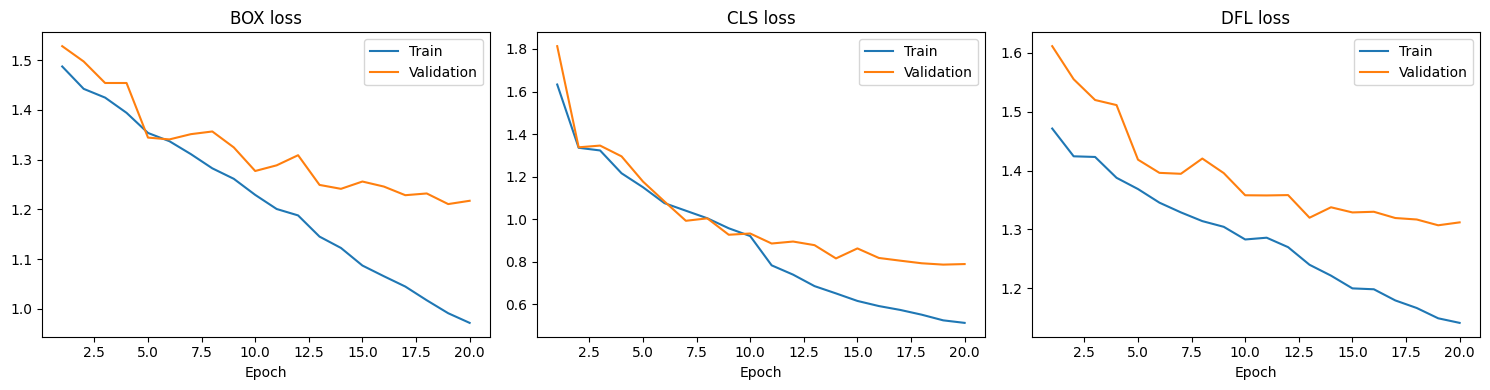

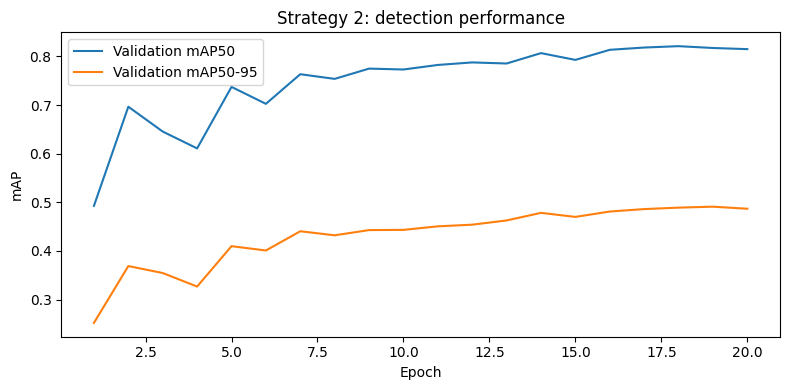

In [13]:
history_2 = pd.read_csv(RUN_2 / "results.csv")
history_2.columns = history_2.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, component in zip(axes, ["box", "cls", "dfl"]):
    ax.plot(history_2["epoch"], history_2[f"train/{component}_loss"], label="Train")
    ax.plot(history_2["epoch"], history_2[f"val/{component}_loss"], label="Validation")
    ax.set_title(f"{component.upper()} loss")
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_2["epoch"], history_2["metrics/mAP50(B)"], label="Validation mAP50")
plt.plot(history_2["epoch"], history_2["metrics/mAP50-95(B)"], label="Validation mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Strategy 2: detection performance")
plt.legend()
plt.tight_layout()
plt.show()

## Step 9 — Compare both models on validation data

Reload `best.pt` from each YOLO11s strategy, evaluate on the same 993 validation images, and compare precision, recall, F1, mAP50, and mAP50-95 overall and per class. Select the higher overall validation mAP50-95; inspect Hardhat and NO-Safety Vest recall before drawing conclusions. Do not use the test split to select a model.


In [12]:
runs = {
    "Frozen backbone": RUN_1,
    "Partial fine-tuning": RUN_2,
}

summary_rows = []
class_rows = []

for strategy_name, run_path in runs.items():
    model = YOLO(str(run_path / "weights" / "best.pt"))

    metrics = model.val(
        data=str(DATA_YAML),
        split="val",
        imgsz=640,
        batch=16,
        device=0,
        workers=2,
        plots=False,
    )

    summary_rows.append({
        "Strategy": strategy_name,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr,
        "F1": metrics.box.f1.mean(),
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map,
    })

    for i, class_id in enumerate(metrics.box.ap_class_index):
        precision, recall, ap50, ap = metrics.box.class_result(i)

        class_rows.append({
            "Strategy": strategy_name,
            "Class": metrics.names[int(class_id)],
            "Precision": precision,
            "Recall": recall,
            "F1": metrics.box.f1[i],
            "mAP50": ap50,
            "mAP50-95": ap,
        })

comparison = pd.DataFrame(summary_rows).set_index("Strategy")
per_class = pd.DataFrame(class_rows).set_index(["Strategy", "Class"])

print("Overall validation results:")
display(comparison.round(3))

print("Validation results for each class:")
display(per_class.round(3))

BEST_NAME = comparison["mAP50-95"].idxmax()
BEST_WEIGHTS = runs[BEST_NAME] / "weights" / "best.pt"
print("Selected model:", BEST_NAME)

Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,414,348 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1557.3±412.7 MB/s, size: 47.6 KB)
val: Scanning /content/ppe_curated_4class_v3_merged_review/valid/labels.cache... 993 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 993/993 260.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 4.3it/s 14.5s
                   all        993       2868      0.732      0.767      0.788       0.47
               Hardhat        160        513      0.735      0.698       0.76      0.444
            NO-Hardhat        234        629      0.835      0.739      0.811       0.47
           Safety Vest        613       1302      0.832      0.866        0.9      0.617
        NO-Safety Vest        201        424      0.524      0.767       0.68      0.347
Speed: 0.9ms p

,Precision,Recall,F1,mAP50,mAP50-95
Strategy,,,,,
Frozen backbone,0.732,0.767,0.743,0.788,0.470
Partial fine-tuning,0.809,0.764,0.784,0.816,0.491


Validation results for each class:


Precision  Recall     F1  mAP50  mAP50-95
Strategy            Class                                                    
Frozen backbone     Hardhat             0.735   0.698  0.716  0.760     0.444
                    NO-Hardhat          0.835   0.739  0.784  0.811     0.470
                    Safety Vest         0.832   0.866  0.848  0.900     0.617
                    NO-Safety Vest      0.524   0.767  0.623  0.680     0.347
Partial fine-tuning Hardhat             0.821   0.766  0.792  0.845     0.493
                    NO-Hardhat          0.895   0.729  0.803  0.818     0.477
                    Safety Vest         0.856   0.871  0.863  0.911     0.632
                    NO-Safety Vest      0.665   0.691  0.678  0.692     0.364

Selected model: Partial fine-tuning


## Step 10 — Final test and saved YOLO11s weights

After reviewing validation results, run the selected YOLO11s checkpoint once on the 500 held-out test images. Save a separate `ppe_yolo11_best.pt` file in Google Drive so the original YOLOv8s checkpoint is preserved. This cell evaluates predictions and copies weights; it does not start training.


In [ ]:
import shutil

final_model = YOLO(str(BEST_WEIGHTS))

test_metrics = final_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    plots=True,
)

test_results = pd.DataFrame([{
    "Precision": test_metrics.box.mp,
    "Recall": test_metrics.box.mr,
    "F1": test_metrics.box.f1.mean(),
    "mAP50": test_metrics.box.map50,
    "mAP50-95": test_metrics.box.map,
}], index=["Test"])

print("Selected strategy:", BEST_NAME)
display(pd.concat([comparison.loc[[BEST_NAME]], test_results]).round(3))

test_class_rows = []
for i, class_id in enumerate(test_metrics.box.ap_class_index):
    precision, recall, ap50, ap = test_metrics.box.class_result(i)
    test_class_rows.append({
        "Class": test_metrics.names[int(class_id)],
        "Precision": precision,
        "Recall": recall,
        "F1": test_metrics.box.f1[i],
        "mAP50": ap50,
        "mAP50-95": ap,
    })

print("Test results for each class:")
display(pd.DataFrame(test_class_rows).set_index("Class").round(3))

EXPORT_PATH = Path("/content/drive/MyDrive/ppe_yolo11_best.pt")
shutil.copy2(BEST_WEIGHTS, EXPORT_PATH)
print("Model saved to:", EXPORT_PATH)

Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,414,348 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1500.4±687.7 MB/s, size: 52.0 KB)
val: Scanning /content/ppe_curated_4class_v3_merged_review/test/labels... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 2.1Kit/s 0.2s
val: New cache created: /content/ppe_curated_4class_v3_merged_review/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 3.3it/s 9.6s
                   all        500       1478      0.792      0.763      0.798      0.472
               Hardhat         81        218      0.803      0.775      0.837      0.473
            NO-Hardhat        127        355      0.818      0.657      0.737      0.434
           Safety Vest        303        667      0.893      0.842      0.912      0.625
        NO-Safety Vest    

,Precision,Recall,F1,mAP50,mAP50-95
Partial fine-tuning,0.809,0.764,0.784,0.816,0.491
Test,0.792,0.763,0.774,0.798,0.472


Test results for each class:


,Precision,Recall,F1,mAP50,mAP50-95
Class,,,,,
Hardhat,0.803,0.775,0.789,0.837,0.473
NO-Hardhat,0.818,0.657,0.729,0.737,0.434
Safety Vest,0.893,0.842,0.867,0.912,0.625
NO-Safety Vest,0.656,0.777,0.711,0.706,0.355


Model saved to: /content/drive/MyDrive/ppe_yolo11_best.pt


In [ ]:
from ultralytics import YOLO

onnx_path = YOLO("/content/drive/MyDrive/ppe_best.pt").export(
    format="onnx",
    imgsz=640,
)
print("ONNX model saved to:", onnx_path)